# 🧠 HAM10000 Skin Classification — Google Colab Training

**EfficientNet-B3 + Transfer Learning + PyTorch**

### Hướng dẫn sử dụng:
1. **Runtime → Change runtime type → GPU (T4)**
2. Upload `kaggle.json` hoặc upload dataset **thủ công** lên Google Drive
3. Chạy từng cell theo thứ tự
4. Model tốt nhất sẽ được lưu vào Google Drive

---

## Step 1: Kiểm tra GPU & Mount Google Drive

In [ ]:
import torch

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✓ GPU: {gpu}  ({mem:.1f} GB VRAM)')
else:
    print('✗ GPU không có sẵn. Vào Runtime → Change runtime type → GPU')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

✓ GPU: Tesla T4  (15.6 GB VRAM)
Using: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted ✓')

Mounted at /content/drive
Google Drive mounted ✓


## Step 2: Tải Dataset HAM10000

**Cách 1 (Khuyến nghị): Kaggle API**
- Tải `kaggle.json` từ https://www.kaggle.com/settings → API
- Upload file lên Colab

**Cách 2: Upload thủ công**
- Tải HAM10000 từ Kaggle về máy
- Upload lên Google Drive rồi điều chỉnh `DATA_DIR`

In [ ]:

import os

DATA_DIR = '/content/drive/MyDrive/HAM10000'  # ← Sửa nếu cần
print(f'Using data from Drive: {DATA_DIR}')

# Verify
import os
csv_path = os.path.join(DATA_DIR, 'HAM10000_metadata.csv')
assert os.path.exists(csv_path), f'Không tìm thấy metadata tại: {csv_path}'
print(f'Data verified ✓  CSV: {csv_path}')

Using data from Drive: /content/drive/MyDrive/HAM10000
Data verified ✓  CSV: /content/drive/MyDrive/HAM10000/HAM10000_metadata.csv


## Step 3: Cài đặt Dependencies

In [ ]:
!pip install -q timm albumentations

## Step 4: Dataset & DataLoaders

In [ ]:
import os, numpy as np, pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2

CLASS_NAMES   = ['akiec','bcc','bkl','df','mel','nv','vasc']
LABEL_MAP     = {n:i for i,n in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = [0.485,0.456,0.406]
IMAGENET_STD  = [0.229,0.224,0.225]
IMAGE_SIZE    = 224

def get_image_path(image_id, data_dir):
    for part in ['HAM10000_images_part_1','HAM10000_images_part_2']:
        p = os.path.join(data_dir, part, f'{image_id}.jpg')
        if os.path.exists(p):
            return p
    # Fallback: flat structure
    p = os.path.join(data_dir, f'{image_id}.jpg')
    return p if os.path.exists(p) else None

def patient_level_split(df, val=0.15, test=0.15, seed=42):
    pts = df['lesion_id'].unique()
    tr_val_pts, te_pts = train_test_split(pts, test_size=test, random_state=seed)
    tr_pts, vl_pts = train_test_split(tr_val_pts, test_size=val/(1-test), random_state=seed)
    return (df[df['lesion_id'].isin(tr_pts)].reset_index(drop=True),
            df[df['lesion_id'].isin(vl_pts)].reset_index(drop=True),
            df[df['lesion_id'].isin(te_pts)].reset_index(drop=True))

def get_transforms(phase='train'):
    size = IMAGE_SIZE
    if phase == 'train':
        return A.Compose([
            A.Resize(size, size),
            A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Affine(scale=(0.85, 1.15),
                     translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                     rotate=(-30, 30), shear=0, border_mode=0, fill=0, p=0.6),
            A.OneOf([
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=35, val_shift_limit=25),
            ], p=0.6),
            A.GaussNoise(p=0.3),
            A.CoarseDropout(num_holes_range=(1, 8),
                            hole_height_range=(28, 28), hole_width_range=(28, 28),
                            fill=0, p=0.3),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()
        ])
    return A.Compose([A.Resize(size, size),
                      A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])

class SkinDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform
        self.labels = df['dx'].map(LABEL_MAP).values.astype(np.int64)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        p   = get_image_path(row['image_id'], self.data_dir)
        img = np.array(Image.open(p).convert('RGB'))
        lbl = int(self.labels[idx])
        if self.transform:
            img = self.transform(image=img)['image']
        return img, lbl

# Load & split
df = pd.read_csv(os.path.join(DATA_DIR, 'HAM10000_metadata.csv'))
train_df, val_df, test_df = patient_level_split(df)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# Datasets
train_ds = SkinDataset(train_df, DATA_DIR, get_transforms('train'))
val_ds   = SkinDataset(val_df,   DATA_DIR, get_transforms('val'))
test_ds  = SkinDataset(test_df,  DATA_DIR, get_transforms('test'))

# Weighted sampler
class_cnt = np.bincount(train_ds.labels, minlength=7)
cw = 1.0 / np.maximum(class_cnt, 1)
sw = cw[train_ds.labels]
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

BATCH_SIZE  = 32   # T4: 32 ok; A100: thử 64
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print('DataLoaders ready ✓')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 6979 | Val: 1493 | Test: 1543
DataLoaders ready ✓
Train batches: 219 | Val batches: 47


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_5687/410152333.py:44: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=28, max_width=28, p=0.3),


## Step 5: Model — EfficientNet-B3

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import timm

NUM_CLASSES = 7

class SkinClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b3', num_classes=NUM_CLASSES,
                 pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained,
                                           num_classes=0, global_pool='avg')
        in_f = self.backbone.num_features  # 1536 for B3
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_f),
            nn.Dropout(dropout),
            nn.Linear(in_f, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(dropout/2),
            nn.Linear(512, num_classes),
        )
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.backbone(x))

class LabelSmoothingLoss(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, smoothing=0.1, class_weights=None):
        super().__init__()
        self.smooth = smoothing
        self.conf   = 1.0 - smoothing
        self.weights = class_weights
    def forward(self, pred, target):
        lp   = F.log_softmax(pred, dim=-1)
        nll  = -lp.gather(-1, target.unsqueeze(1)).squeeze(1)
        smo  = -lp.mean(-1)
        loss = self.conf * nll + self.smooth * smo
        if self.weights is not None:
            loss = loss * self.weights[target]
        return loss.mean()

# Class weights from training data
cw_tensor = torch.FloatTensor(cw / cw.sum() * NUM_CLASSES).to(device)

model     = SkinClassifier(pretrained=True).to(device)
criterion = LabelSmoothingLoss(class_weights=cw_tensor)

total     = sum(p.numel() for p in model.parameters())
print(f'Model: EfficientNet-B3')
print(f'Total parameters: {total:,}')
print(f'Device: {device}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model: EfficientNet-B3
Total parameters: 11,490,863
Device: cuda


## Step 6: Optimizer & Scheduler

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

EPOCHS        = 50
LR            = 1e-3
WARMUP_EPOCHS = 5
PATIENCE      = 10

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(),   'lr': LR * 0.1},  # Backbone: lr thấp hơn
    {'params': model.classifier.parameters(), 'lr': LR},        # Head: lr bình thường
], weight_decay=1e-4)

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-7)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

print(f'Optimizer: AdamW  (backbone lr={LR*0.1:.1e}, head lr={LR:.1e})')
print(f'Scheduler: Warmup({WARMUP_EPOCHS}ep) → CosineAnnealing({EPOCHS-WARMUP_EPOCHS}ep)')

Optimizer: AdamW  (backbone lr=1.0e-04, head lr=1.0e-03)
Scheduler: Warmup(5ep) → CosineAnnealing(45ep)


## Step 7: Training Loop

In [ ]:
import time
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm

SAVE_DIR = '/content/drive/MyDrive/skin_classification_models'
os.makedirs(SAVE_DIR, exist_ok=True)

scaler = GradScaler()
history = {'train_loss':[], 'val_loss':[], 'train_f1':[], 'val_f1':[], 'lr':[]}
best_val_f1 = 0.0
patience_counter = 0

def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, lbls in tqdm(loader, leave=False, desc='Train' if is_train else '  Val'):
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, lbls)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, lbls)
            total_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, f1

print(f'Starting training — {EPOCHS} epochs max, early stopping patience={PATIENCE}')
print('='*65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_f1 = run_epoch(train_loader, is_train=True)
    vl_loss, vl_f1 = run_epoch(val_loader,   is_train=False)
    scheduler.step()
    lr = optimizer.param_groups[-1]['lr']

    for k, v in [('train_loss', tr_loss),('val_loss', vl_loss),
                  ('train_f1', tr_f1),('val_f1', vl_f1),('lr', lr)]:
        history[k].append(v)

    elapsed = time.time() - t0
    flag = '  ✓ BEST' if vl_f1 > best_val_f1 else ''
    print(f'[{epoch:>3}/{EPOCHS}]  '
          f'TrLoss={tr_loss:.4f} TrF1={tr_f1:.4f}  '
          f'VlLoss={vl_loss:.4f} VlF1={vl_f1:.4f}  '
          f'LR={lr:.1e}  {elapsed:.0f}s{flag}')

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        patience_counter = 0
        save_path = os.path.join(SAVE_DIR, 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': vl_f1,
            'history': history,
        }, save_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\n✅ Best Val F1: {best_val_f1:.4f}')
print(f'   Model saved → {save_path}')

Starting training — 50 epochs max, early stopping patience=10


/tmp/ipykernel_5687/3398073357.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Train:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_5687/3398073357.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Val:   0%|          | 0/47 [00:00<?, ?it/s]

...

Train:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_5687/3398073357.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  Val:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_5687/3398073357.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[ 50/50]  TrLoss=0.5116 TrF1=0.8890  VlLoss=0.2148 VlF1=0.7382  LR=1.0e-07  116s

✅ Best Val F1: 0.7539
   Model saved → /content/drive/MyDrive/skin_classification_models/best_model.pth


## Step 8: Training Curves

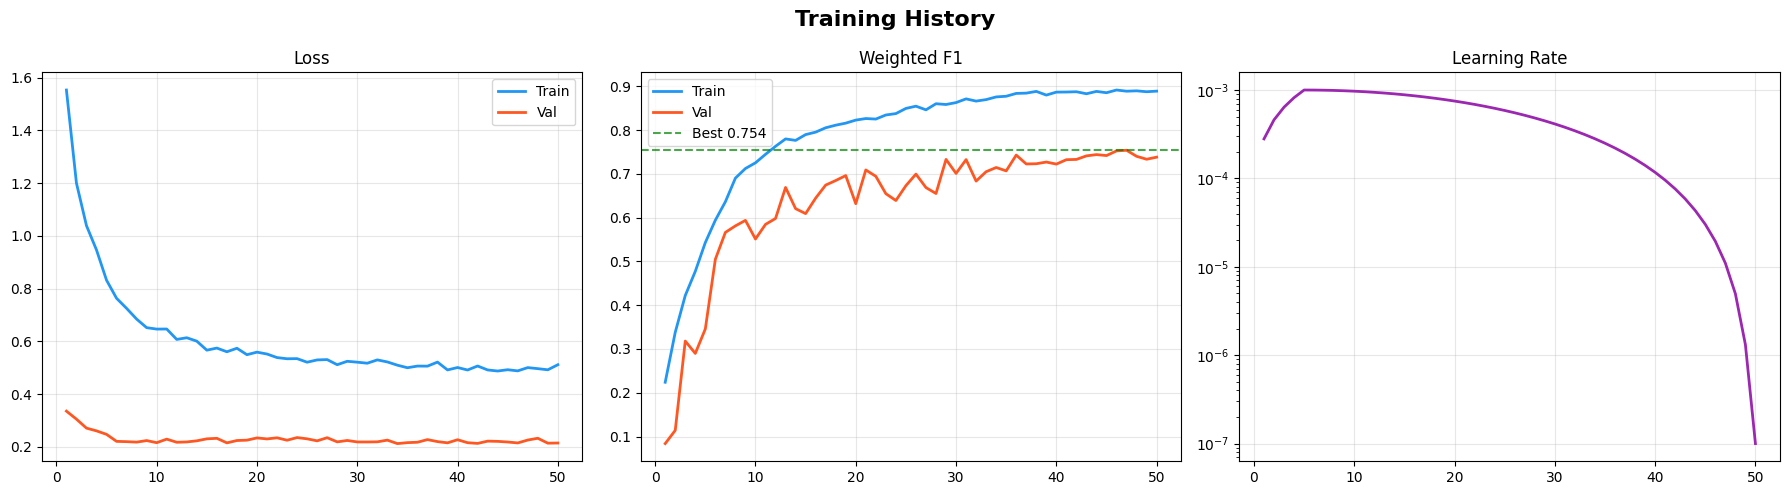

Saved → /content/drive/MyDrive/skin_classification_models/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='#2196F3', lw=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='#FF5722', lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_f1'], label='Train', color='#2196F3', lw=2)
axes[1].plot(epochs_ran, history['val_f1'],   label='Val',   color='#FF5722', lw=2)
axes[1].axhline(y=best_val_f1, color='green', ls='--', alpha=0.7, label=f'Best {best_val_f1:.3f}')
axes[1].set_title('Weighted F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, history['lr'], color='#9C27B0', lw=2)
axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, 'training_curves.png')
plt.savefig(curve_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → {curve_path}')

## Step 9: Evaluation trên Test Set

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, balanced_accuracy_score,
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Load best model
checkpoint = torch.load(os.path.join(SAVE_DIR, 'best_model.pth'), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]} (Val F1: {checkpoint["val_f1"]:.4f})')

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(device)
        with autocast():
            out   = model(imgs)
            probs = torch.softmax(out, dim=1)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# Metrics
w_f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
m_f1   = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
bal_acc = balanced_accuracy_score(all_labels, all_preds)
y_bin  = label_binarize(all_labels, classes=list(range(7)))
macro_auc = roc_auc_score(y_bin, all_probs, average='macro', multi_class='ovr')

print('\n' + '='*55)
print('  TEST SET RESULTS')
print('='*55)
print(f'  Weighted F1      : {w_f1:.4f}')
print(f'  Macro F1         : {m_f1:.4f}')
print(f'  Balanced Accuracy: {bal_acc:.4f}')
print(f'  Macro AUC-ROC    : {macro_auc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

Loaded checkpoint from epoch 47 (Val F1: 0.7539)


Testing:   0%|          | 0/49 [00:00<?, ?it/s]

/tmp/ipykernel_5687/2464142383.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



  TEST SET RESULTS
  Weighted F1      : 0.7529
  Macro F1         : 0.6730
  Balanced Accuracy: 0.7048
  Macro AUC-ROC    : 0.9427

              precision    recall  f1-score   support

       akiec       0.58      0.60      0.59        52
         bcc       0.80      0.80      0.80        94
         bkl       0.61      0.72      0.66       180
          df       0.75      0.41      0.53        29
         mel       0.37      0.82      0.51       176
          nv       0.95      0.72      0.82       983
        vasc       0.74      0.86      0.79        29

    accuracy                           0.73      1543
   macro avg       0.69      0.70      0.67      1543
weighted avg       0.82      0.73      0.75      1543



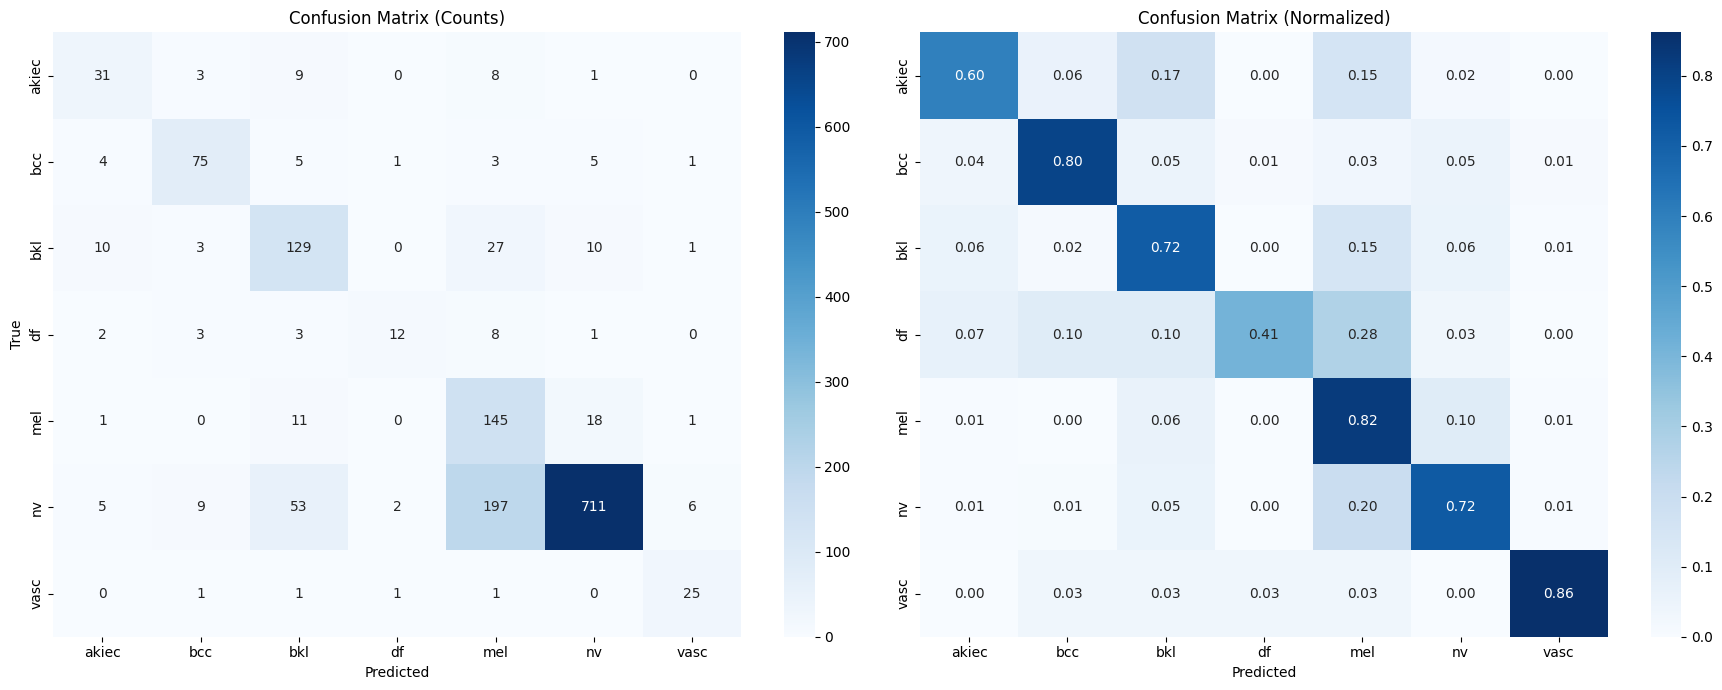

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
kw = dict(xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', ax=axes[0], **kw)
axes[0].set_title('Confusion Matrix (Counts)');   axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], **kw)
axes[1].set_title('Confusion Matrix (Normalized)'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=130, bbox_inches='tight')
plt.show()

## Step 10: Sao chép Model về Local (để dùng với Web App)

In [ ]:
# Model đã được lưu tại: SAVE_DIR/best_model.pth
# Download về máy local:
from google.colab import files
files.download(os.path.join(SAVE_DIR, 'best_model.pth'))
print('Downloading best_model.pth ...')
print('Sau khi tải xong, đặt file vào thư mục: Skin_Classification/models/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Sau khi tải xong, đặt file vào thư mục: Skin_Classification/models/


## ✅ Hoàn thành!

### Bước tiếp theo:
1. **Download** `best_model.pth` từ cell trên
2. **Đặt file** vào `Skin_Classification/models/best_model.pth`
3. **Chạy web app**: `python web/app.py`
4. **Mở browser**: http://localhost:5000

### Kết quả mong đợi:
| Metric | Target |
|--------|--------|
| Weighted F1 | ≥ 0.78 |
| Macro AUC-ROC | ≥ 0.85 |
| Melanoma Recall | ≥ 0.75 |